# 05 - Class Distribution

**Goal:** Visualize the number of images per class as a bar chart — useful for understanding class imbalance and for including in the dissertation.

| Info | Value |
|------|-------|
| Dataset | PlantVillage |
| Task | Multi-Crop Disease Detection |
| Phase | 5 — Class Distribution |

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

DATASET_PATH = "../dataset/PlantVillage"

In [2]:
# Count images per class
class_counts = {}

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)
    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        class_counts[class_name] = len(images)

# Sort by count descending
class_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

print(f"Total Classes : {len(class_counts)}")
print(f"Total Images  : {sum(class_counts.values())}")

Total Classes : 38
Total Images  : 54305


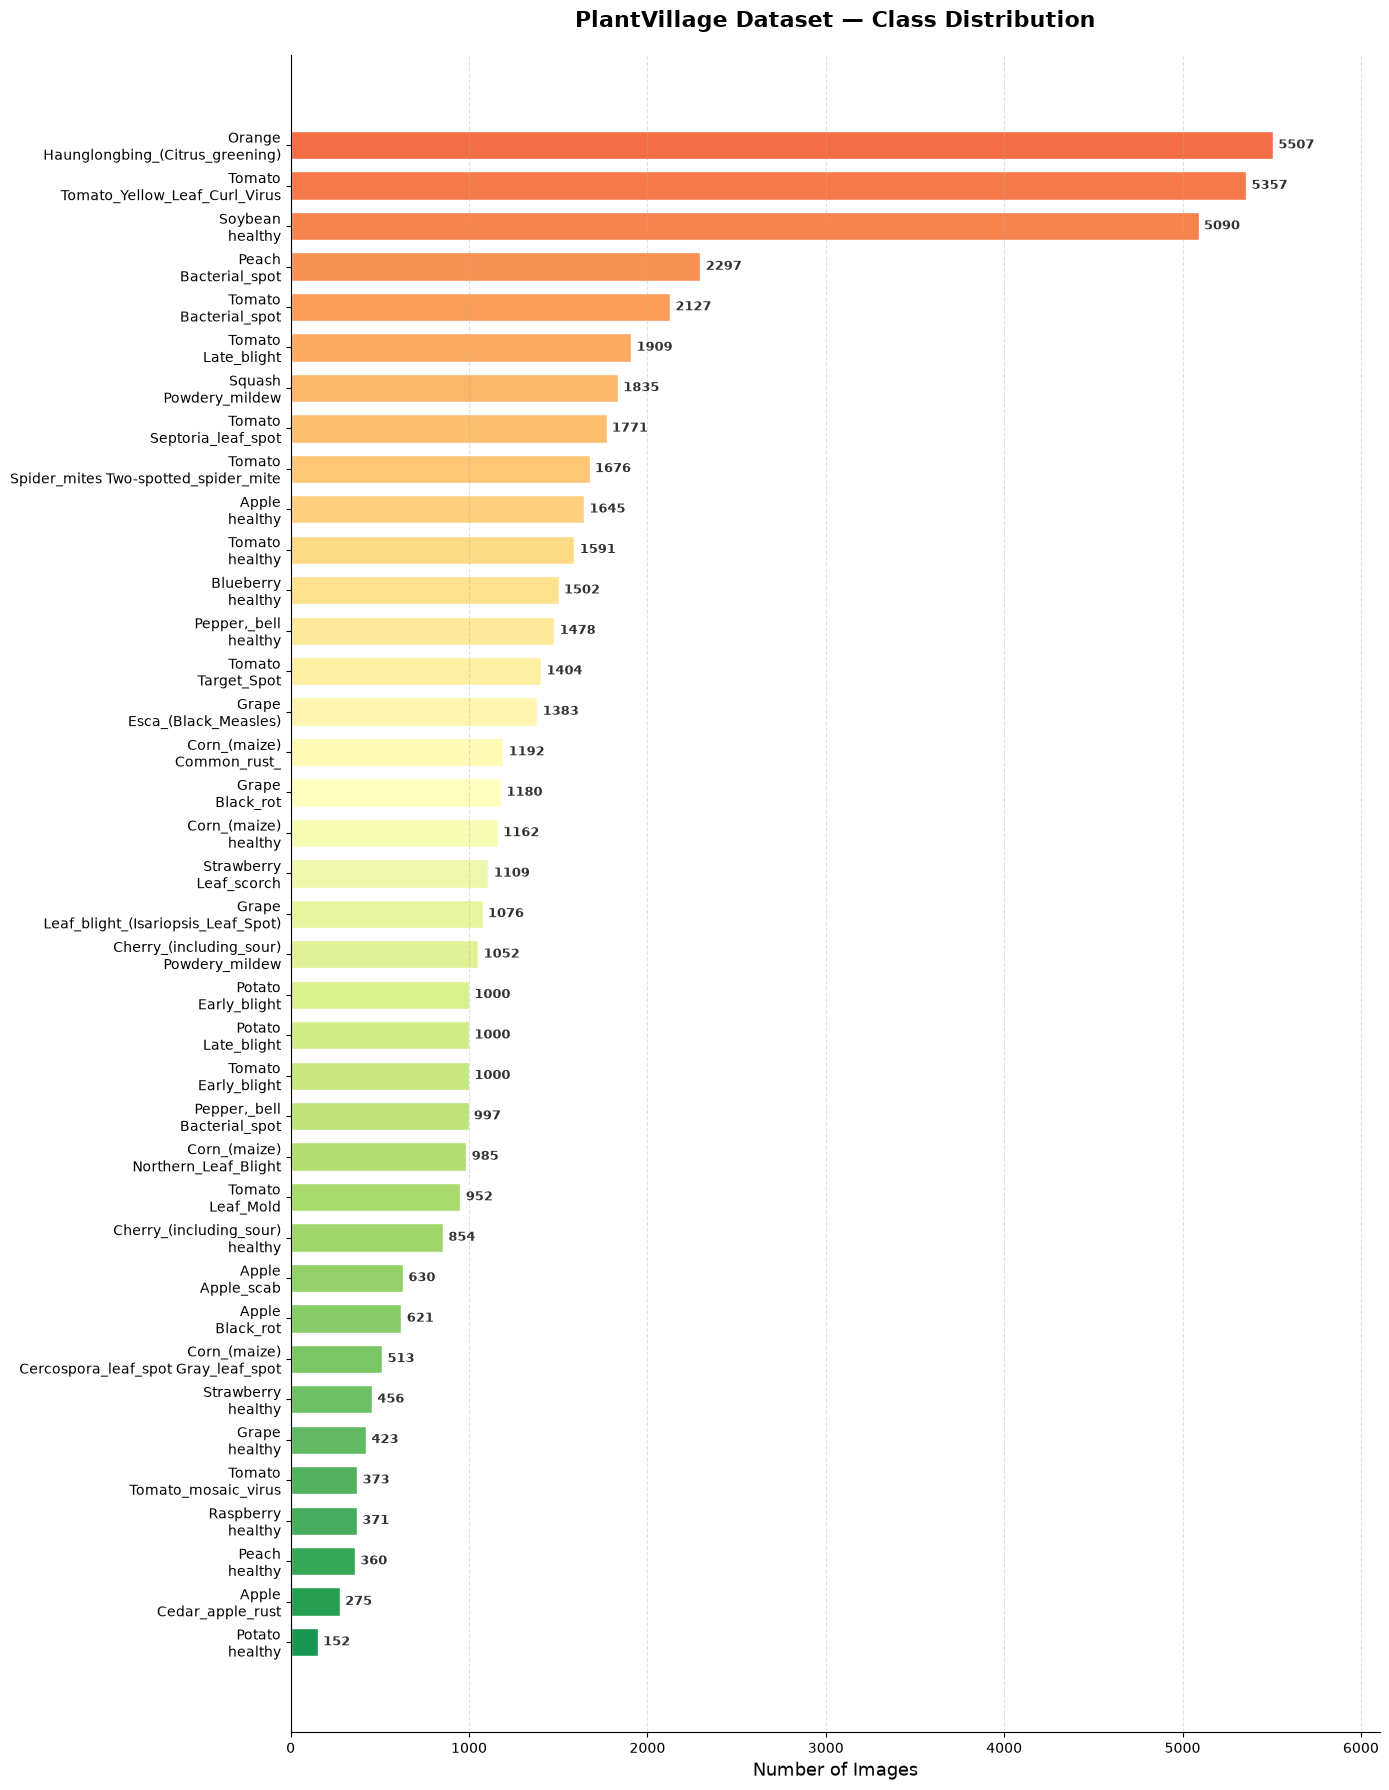


✅ Chart saved as: class_distribution.png


In [3]:
# Horizontal Bar Chart - Dissertation Ready
labels = [k.replace("___", "\n") for k in class_counts.keys()]
values = list(class_counts.values())

colors = cm.RdYlGn(np.linspace(0.2, 0.9, len(values)))

fig, ax = plt.subplots(figsize=(14, 18))

bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.7)

# Add count labels on bars
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            str(val), va='center', fontsize=9, fontweight='bold', color='#333')

ax.set_xlabel("Number of Images", fontsize=13)
ax.set_title("PlantVillage Dataset — Class Distribution", fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.set_xlim(0, max(values) + 600)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Chart saved as: class_distribution.png")